# Loading dataset from the data folder


In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


DATA_DIR = Path("data/wisdm-dataset")

RAW_DATA_DIR = DATA_DIR / "raw"


ACTIVITY_MAP = {
    "A": "walking",
    "B": "jogging",
    "C": "stairs",
    "D": "sitting",
    "E": "standing",
    "F": "typing",
    "G": "teeth",
    "H": "soup",
    "I": "chips",
    "J": "pasta",
    "K": "drinking",
    "L": "sandwich",
    "M": "kicking",
    "O": "catch",
    "P": "dribbling",
    "Q": "writing",
    "R": "clapping",
    "S": "folding",
}

ACTIVITIES = list(ACTIVITY_MAP.keys())

In [2]:
ACTIVITIES

['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'O',
 'P',
 'Q',
 'R',
 'S']

In [3]:
ACTIVITY_MAP

{'A': 'walking',
 'B': 'jogging',
 'C': 'stairs',
 'D': 'sitting',
 'E': 'standing',
 'F': 'typing',
 'G': 'teeth',
 'H': 'soup',
 'I': 'chips',
 'J': 'pasta',
 'K': 'drinking',
 'L': 'sandwich',
 'M': 'kicking',
 'O': 'catch',
 'P': 'dribbling',
 'Q': 'writing',
 'R': 'clapping',
 'S': 'folding'}

In [4]:
devices = (
    "phone",
    "watch",
)
sensors = (
    "accel",
    "gyro",
)
COLUMNS = ["id", "activity", "timestamp", "x", "y", "z"]

### Accel

- Provides the acceleration along the three axis based on the devices
- m/s^2

### Gyro

- Provides the angular velocity on each axis based on the device
- rad/s

### Magnitude

sq(x^2 + y^2 + z^2)


In [16]:
def magnitude(x, y, z):
    return np.sqrt(x**2 + y**2 + z**2)


def estimate_hz(df: pd.DataFrame) -> float:
    dts = df.groupby("activity", sort=False)["timestamp"].diff().dropna()
    med = dts.median()
    return float(1e9 / med) if med and med > 0 else float("nan")


def load_data(file_path: Path):
    df = pd.read_csv(
        file_path,
        header=None,
        names=COLUMNS,
        converters={"z": lambda z: str(z).rstrip(";")},  # remove the last ; line break
    )
    df["activity_name"] = df["activity"].map(ACTIVITY_MAP)
    df["z"] = df["z"].astype(float)
    df["magnitude"] = magnitude(df["x"], df["y"], df["z"])
    return df

In [20]:
# Each data files study on 51 subjects for 4 streams: device and sensor
rows = []
for device in devices:
    for sensor in sensors:
        for path in sorted((RAW_DATA_DIR / device / sensor).glob("data_*.txt")):
            tmp = load_data(path)
            acts = set(tmp["activity"])
            rows.append(
                {
                    "device": device,
                    "sensor": sensor,
                    "subject": int(tmp["id"].iloc[0]),
                    "n_rows": len(tmp),
                    "n_acts": tmp["activity"].nunique(),
                    "missing": ",".join(
                        ACTIVITY_MAP.get(a, "UNIDENTIFIED")
                        for a in ACTIVITIES
                        if a not in acts
                    ),
                    "hz": estimate_hz(tmp),
                    "null_xyz": int(tmp[["x", "y", "z"]].isna().any(axis=1).sum()),
                }
            )

## Missing Informations

In [19]:
print(
    inv[inv["n_acts"] != 18][["device", "sensor", "subject", "n_acts", "missing", "hz"]]
)
print("\nPhone accel Hz buckets:")
print(
    inv.query("device=='phone' and sensor=='accel'")["hz"]
    .round()
    .value_counts()
    .sort_index()
)

    device sensor  subject  n_acts          missing         hz
7    phone  accel     1607      17            pasta  25.059388
9    phone  accel     1609      17          jogging  19.859394
16   phone  accel     1616      16   jogging,typing  49.648484
18   phone  accel     1618      17            catch  19.859394
42   phone  accel     1642      16    stairs,typing  49.761146
43   phone  accel     1643      17            chips  49.761146
58   phone   gyro     1607      17            pasta  25.059417
60   phone   gyro     1609      17          jogging  19.859394
67   phone   gyro     1616      16   jogging,typing  19.859394
69   phone   gyro     1618      17            catch  19.859394
92   phone   gyro     1641      17          writing  24.817591
93   phone   gyro     1642      16    stairs,typing  24.814512
94   phone   gyro     1643      17            chips  24.810202
95   phone   gyro     1644      17         sandwich  24.812049
118  watch  accel     1616      17          jogging  20

#### Class Imbalance check

In [ ]:
# for device phone and sensor accel
phone_accel = []
for path in sorted((RAW_DATA_DIR / "phone" / "accel").glob("data_*.txt")):
    tmp = load_data(path)
    phone_accel.append(tmp["activity_name"].value_counts())
counts = pd.concat(phone_accel, axis=1).sum(axis=1).sort_values()

counts = counts.rename("n_samples")
counts.to_frame().assign(pct=lambda d: 100 * d["n_samples"] / d["n_samples"].sum())

activity_name
typing     246356.0
pasta      249793.0
stairs     255645.0
writing    260497.0
chips      261360.0
dtype: float64


,n_samples,pct
activity_name,,
typing,246356.0,5.127713
pasta,249793.0,5.199252
stairs,255645.0,5.321057
writing,260497.0,5.422047
chips,261360.0,5.440010
sitting,264592.0,5.507282
folding,265214.0,5.520228
sandwich,265781.0,5.532030
clapping,268065.0,5.579569


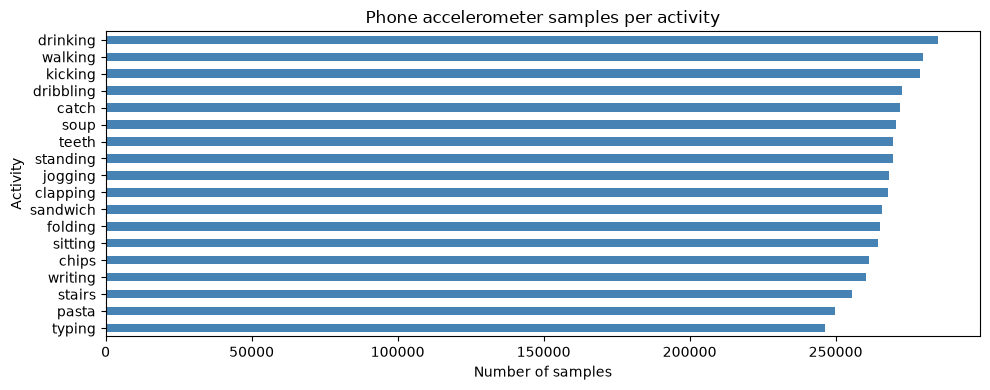

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Phone accelerometer samples per activity")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Activity")
plt.tight_layout()
plt.show()